## Data Sources

This project uses data from two public sources:

1. **iPhone 18 Pro Prices**
   - Source: Pippin iPhone international price database
   - Pippin collects prices from official Apple Stores across different countries.
   - Model used: **iPhone 18 Pro, 256 GB**
   - Prices used: **Retail price including tax**
   - Local currency prices were recorded for the 10 countries included in this analysis.
   - Price data was collected in September 2026.

2. **Average Monthly Earnings**
   - Source: International Labour Organization (ILOSTAT)
   - Dataset: Average monthly earnings of employees by country.
   - The **Total** value was used, representing average earnings across all employees rather than separating male and female workers.
   - The most recent available year for each country was used.
   - Earnings in this dataset are reported in PPP-adjusted U.S. dollars.

### Note
The latest available wage year differs between countries because not every country reports earnings data for the same year.

In [45]:
# importing libraries
%pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# Loading data

wages_df = pd.read_csv("C:/Users/FX516PC/Desktop/Gs/MC datasets/Iphone prices vs wages/EAR_EMTA_SEX_CUR_NB_A-20260923T2101.csv")

iphone_df = pd.read_excel("C:/Users/FX516PC/Desktop/Gs/MC datasets/Iphone prices vs wages/iphone_prices.xlsx")

In [47]:
wages_df.head()

,Area,Year,Total,Male,Female,Other
0,Aruba,2010,1860.382,2061.054,1675.147,NaN
1,Afghanistan,2020,836.263,851.284,686.841,NaN
2,Angola,2024,359.487,391.584,289.981,NaN
3,Albania,2022,1266.603,1304.970,1223.938,NaN
4,United Arab Emirates,2009,3017.269,3206.372,2247.971,NaN


In [48]:
iphone_df.head()

,Country,Currency,iPhone 18 Pro 256 GB Price,price in USD
0,USA,USD,1295,1295
1,IND,INR,164900,1722
2,UK,GBP,1199,1592
3,GER,EU,1449,1653
4,JAP,YEN,219800,1392


In [49]:
# Data Cleaning

wages_df = wages_df[["Area" ,"Year", "Total" ]]
wages_df.head()

,Area,Year,Total
0,Aruba,2010,1860.382
1,Afghanistan,2020,836.263
2,Angola,2024,359.487
3,Albania,2022,1266.603
4,United Arab Emirates,2009,3017.269


In [50]:
# Renaming the columns
wages_df = wages_df.rename(columns={
    "Area": "Country",
    "Year": "Wage_Year",
    "Total": "Monthly_Earnings_PPP"
})

wages_df.head()

,Country,Wage_Year,Monthly_Earnings_PPP
0,Aruba,2010,1860.382
1,Afghanistan,2020,836.263
2,Angola,2024,359.487
3,Albania,2022,1266.603
4,United Arab Emirates,2009,3017.269


In [51]:
iphone_df = iphone_df.rename(columns={
    "iPhone 18 Pro 256 GB Price": "iPhone_Price"
})

iphone_df.head()

,Country,Currency,iPhone_Price,price in USD
0,USA,USD,1295,1295
1,IND,INR,164900,1722
2,UK,GBP,1199,1592
3,GER,EU,1449,1653
4,JAP,YEN,219800,1392


In [52]:
# Renaming country abbreviation to country names
country_names = {
    "USA": "United States",
    "IND": "India",
    "UK": "United Kingdom of Great Britain and Northern Ireland",
    "GER": "Germany",
    "JAP": "Japan",
    "AUS": "Australia",
    "CAN": "Canada",
    "UAE": "United Arab Emirates",
    "BRA": "Brazil"
}

iphone_df["Country"] = iphone_df["Country"].replace(country_names)

currency_names = {
    "EU": "EUR",
    "YEN": "JPY"
}

iphone_df["Currency"] = iphone_df["Currency"].replace(currency_names)

In [53]:
iphone_df

,Country,Currency,iPhone_Price,price in USD
0,United States,USD,1295,1295
1,India,INR,164900,1722
2,United Kingdom of Great Britain and Northern I...,GBP,1199,1592
3,Germany,EUR,1449,1653
4,Japan,JPY,219800,1392
5,Australia,AUD,2099,1483
6,Canada,CAD,1976,1403
7,United Arab Emirates,AED,5099,1383
8,Brazil,BRL,11999,2338
9,Republic of Korea,KO,1990000,1458


In [54]:
for country in iphone_df["Country"]:
    print(country, country in wages_df["Country"].values)

United States False
India True
United Kingdom of Great Britain and Northern Ireland True
Germany True
Japan True
Australia True
Canada True
United Arab Emirates True
Brazil True
Republic of Korea True


In [55]:
wages_df[wages_df["Country"].str.contains("Kingdom", case=False, na=False)]

,Country,Wage_Year,Monthly_Earnings_PPP
55,United Kingdom of Great Britain and Northern I...,2025,4499.877


In [56]:
iphone_df["Country"] = iphone_df["Country"].replace({
    "United States": "United States of America"
})

In [57]:
for country in iphone_df["Country"]:
    print(country, country in wages_df["Country"].values)

United States of America True
India True
United Kingdom of Great Britain and Northern Ireland True
Germany True
Japan True
Australia True
Canada True
United Arab Emirates True
Brazil True
Republic of Korea True


In [58]:
iphone_df = iphone_df.rename(columns={
    "price in USD": "iPhone_Price_USD"
})

In [59]:
iphone_df.head()

,Country,Currency,iPhone_Price,iPhone_Price_USD
0,United States of America,USD,1295,1295
1,India,INR,164900,1722
2,United Kingdom of Great Britain and Northern I...,GBP,1199,1592
3,Germany,EUR,1449,1653
4,Japan,JPY,219800,1392


In [60]:
# Merging the datasets
combined_df = pd.merge(
    iphone_df,
    wages_df,
    on="Country",
    how="inner"
)

combined_df

,Country,Currency,iPhone_Price,iPhone_Price_USD,Wage_Year,Monthly_Earnings_PPP
0,United States of America,USD,1295,1295,2025,6272.925
1,India,INR,164900,1722,2025,1120.020
2,United Kingdom of Great Britain and Northern I...,GBP,1199,1592,2025,4499.877
3,Germany,EUR,1449,1653,2022,6134.911
4,Japan,JPY,219800,1392,2021,2808.732
5,Australia,AUD,2099,1483,2021,3925.805
6,Canada,CAD,1976,1403,2025,4571.222
7,United Arab Emirates,AED,5099,1383,2009,3017.269
8,Brazil,BRL,11999,2338,2025,1314.417
9,Republic of Korea,KO,1990000,1458,2022,4525.448


In [61]:
combined_df.shape

(10, 6)

In [62]:
# Analysis
combined_df["Affordability_Ratio"] = (
    combined_df["iPhone_Price_USD"] /
    combined_df["Monthly_Earnings_PPP"]
)

In [63]:
combined_df[
    ["Country", "iPhone_Price_USD",
     "Monthly_Earnings_PPP", "Affordability_Ratio"]
]

,Country,iPhone_Price_USD,Monthly_Earnings_PPP,Affordability_Ratio
0,United States of America,1295,6272.925,0.206443
1,India,1722,1120.020,1.537473
2,United Kingdom of Great Britain and Northern I...,1592,4499.877,0.353787
3,Germany,1653,6134.911,0.269442
4,Japan,1392,2808.732,0.495597
5,Australia,1483,3925.805,0.377757
6,Canada,1403,4571.222,0.306920
7,United Arab Emirates,1383,3017.269,0.458362
8,Brazil,2338,1314.417,1.778735
9,Republic of Korea,1458,4525.448,0.322178


In [64]:
# Sorting them
affordability_df = combined_df.sort_values(
    "Affordability_Ratio"
)

affordability_df[
    ["Country", "Affordability_Ratio"]
]

,Country,Affordability_Ratio
0,United States of America,0.206443
3,Germany,0.269442
6,Canada,0.306920
9,Republic of Korea,0.322178
2,United Kingdom of Great Britain and Northern I...,0.353787
5,Australia,0.377757
7,United Arab Emirates,0.458362
4,Japan,0.495597
1,India,1.537473
8,Brazil,1.778735


In [65]:
# Visualization
country_labels = {
    "United States of America": "USA",
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "United Arab Emirates": "UAE",
    "Republic of Korea": "South Korea"
}

combined_df["Country_Short"] = combined_df["Country"].replace(country_labels)

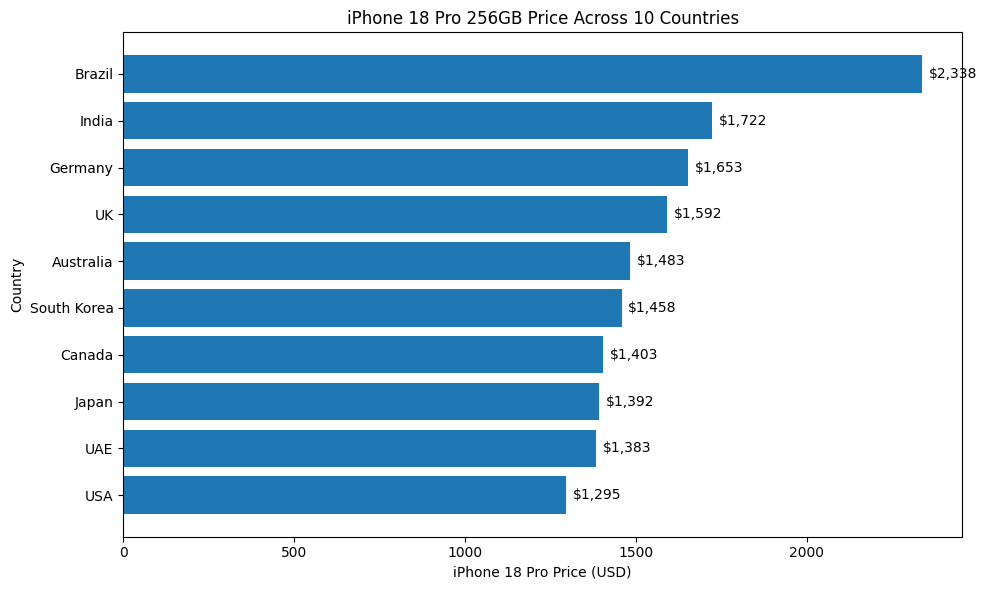

In [67]:
price_df = combined_df.sort_values(
    "iPhone_Price_USD",
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    price_df["Country_Short"],
    price_df["iPhone_Price_USD"]
)

plt.xlabel("iPhone 18 Pro Price (USD)")
plt.ylabel("Country")
plt.title("iPhone 18 Pro 256GB Price Across 10 Countries")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"${width:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

Where is the iphone pro most expensive

In [68]:
combined_df["Affordability_Ratio"] = (
    combined_df["iPhone_Price_USD"] /
    combined_df["Monthly_Earnings_PPP"]
)

In [69]:
combined_df["Affordability_Index"] = (
    combined_df["Affordability_Ratio"] * 100
)

In [70]:
affordability_df = combined_df.sort_values(
    "Affordability_Index",
    ascending=False
)

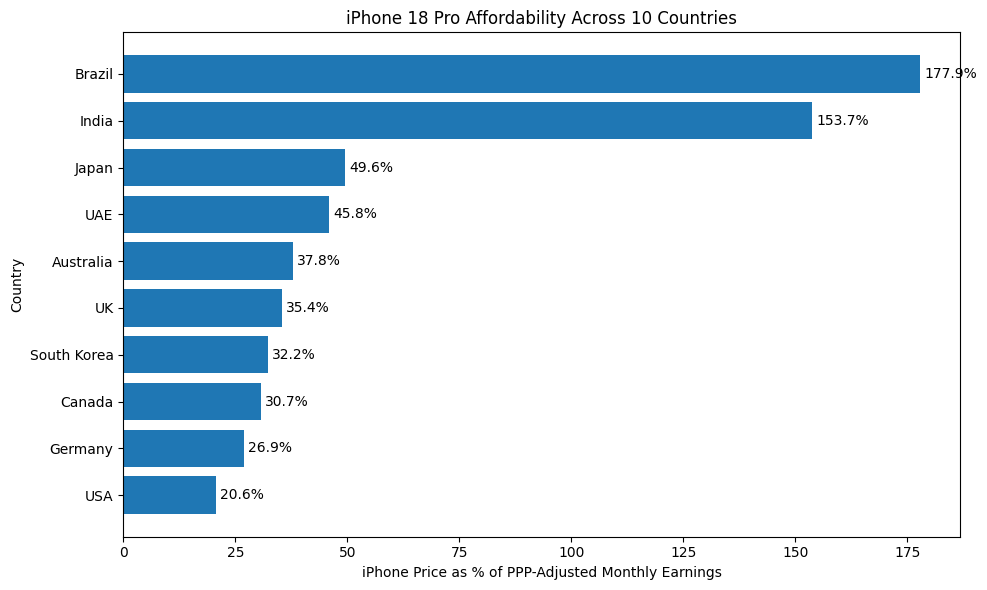

In [71]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    affordability_df["Country_Short"],
    affordability_df["Affordability_Index"]
)

plt.xlabel("iPhone Price as % of PPP-Adjusted Monthly Earnings")
plt.ylabel("Country")
plt.title("iPhone 18 Pro Affordability Across 10 Countries")

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

In [76]:
combined_df["Weeks_Needed"] = (
    combined_df["iPhone_Price_USD"] /
    combined_df["Monthly_Earnings_PPP"]
) * 4.345

In [77]:
combined_df[
    ["Country_Short", "iPhone_Price_USD",
     "Monthly_Earnings_PPP", "Weeks_Needed"]
]

,Country_Short,iPhone_Price_USD,Monthly_Earnings_PPP,Weeks_Needed
0,USA,1295,6272.925,0.896994
1,India,1722,1120.020,6.680318
2,UK,1592,4499.877,1.537206
3,Germany,1653,6134.911,1.170724
4,Japan,1392,2808.732,2.153370
5,Australia,1483,3925.805,1.641354
6,Canada,1403,4571.222,1.333568
7,UAE,1383,3017.269,1.991581
8,Brazil,2338,1314.417,7.728605
9,South Korea,1458,4525.448,1.399864


In [78]:
combined_df["Weeks_Needed"] = combined_df["Weeks_Needed"].round(1)

In [79]:
weeks_df = combined_df.sort_values(
    "Weeks_Needed",
    ascending=True
)

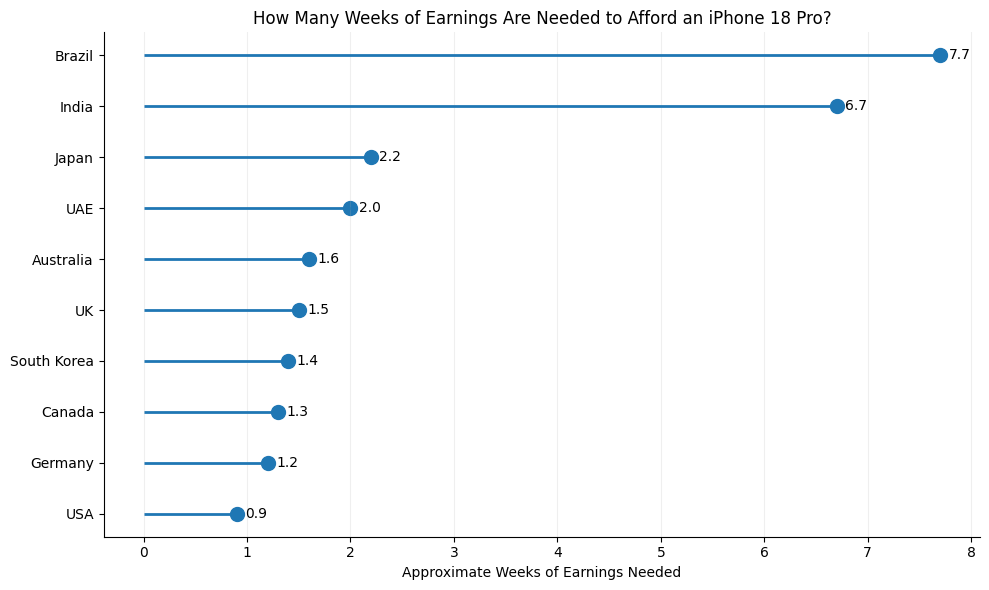

In [80]:
plt.figure(figsize=(10, 6))

plt.hlines(
    y=weeks_df["Country_Short"],
    xmin=0,
    xmax=weeks_df["Weeks_Needed"],
    linewidth=2
)

plt.scatter(
    weeks_df["Weeks_Needed"],
    weeks_df["Country_Short"],
    s=100
)

for _, row in weeks_df.iterrows():
    plt.text(
        row["Weeks_Needed"] + 0.08,
        row["Country_Short"],
        f'{row["Weeks_Needed"]:.1f}',
        va="center"
    )

plt.xlabel("Approximate Weeks of Earnings Needed")
plt.ylabel("")

plt.title(
    "How Many Weeks of Earnings Are Needed to Afford an iPhone 18 Pro?"
)

plt.grid(axis="x", alpha=0.2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()